# 14. Monitoring and Drift Demo

The API can be technically healthy while the model becomes less useful in practice. A `/health` endpoint only tells us that the service is running. It does not tell us whether incoming customers still look like the training data.

In this notebook, we use a small local monitoring setup:

- the FastAPI service logs incoming requests and predictions to SQLite;
- the database is stored in `monitoring/predictions.db`;
- Docker Compose mounts `monitoring/` as a writable volume;
- this notebook compares logged requests with reference training data.

The structure follows common patterns from model monitoring tools such as Evidently, NannyML, Azure ML Model Monitoring, AWS SageMaker Model Monitor, and Vertex AI Model Monitoring: reference data versus current data, data quality checks, data drift checks, prediction monitoring, and alert-style summaries.

## 1. Why Monitoring Matters

Machine learning systems can fail silently. The API may still return status code `200`, but the world around the model may have changed.

Examples:

- incoming customers may have a different age distribution than the training population;
- account balances may become much higher or lower;
- the bank may use different contact methods or contact customers in different months;
- marketing campaigns may require more customer contacts than before.

These changes do not necessarily crash the pipeline, but they can make model predictions less reliable.

La celda de imports que aparece debajo es general y no cambia:

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, ks_2samp


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data").exists() and (path / "src").exists():
            return path
    raise FileNotFoundError("Could not find project root. Please run this notebook inside the project repository.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import clean_bank_marketing_data, load_raw_data
from src.serving.monitoring import get_monitoring_db_path, load_prediction_logs

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "bank-full.csv"
MODEL_RESULTS_DIR = PROJECT_ROOT / "reports" / "model_results"

plt.style.use("default")


## 2. Reference Data

The reference distribution usually comes from the training data. In a production setup, teams often define a specific reference window, for example the training snapshot or the last stable production month.

Here, we use the cleaned Bank Marketing training dataset as reference.

In [3]:
reference_df = clean_bank_marketing_data(load_raw_data(RAW_DATA_PATH))
reference_df[["age", "balance", "campaign", "pdays", "previous", "job", "contact", "month"]].head()

,age,balance,campaign,pdays,previous,job,contact,month
0,58,2143,1,-1,0,management,unknown,may
1,44,29,1,-1,0,technician,unknown,may
2,33,2,1,-1,0,entrepreneur,unknown,may
3,47,1506,1,-1,0,blue-collar,unknown,may
4,33,1,1,-1,0,unknown,unknown,may


## 3. Prediction Logs

The API writes one row per successful prediction. Each row contains:

- timestamp;
- selected input features;
- the full original request as JSON;
- prediction probability and class;
- model name and model version.

If no API calls have been logged yet, this notebook creates a synthetic current sample for demonstration. That sample is not written to the database.

In [4]:
monitoring_db_path = get_monitoring_db_path()
logged_predictions = load_prediction_logs(monitoring_db_path)

if logged_predictions.empty:
    rng = np.random.default_rng(42)
    current_df = reference_df.sample(n=400, random_state=42).copy()

    # Demonstration drift: older customers, higher balances,
    # more campaign contacts, and changes in contact type and month.
    current_df["age"] = np.minimum(
        95,
        (current_df["age"] * rng.uniform(1.05, 1.25, len(current_df))).round(),
    ).astype(int)
    current_df["balance"] = (
        current_df["balance"] + rng.normal(1000, 500, len(current_df))
    ).round()
    current_df["campaign"] = np.maximum(
        1,
        (current_df["campaign"] * rng.uniform(1.2, 2.5, len(current_df))).round(),
    ).astype(int)
    current_df.loc[
        current_df.sample(frac=0.35, random_state=43).index,
        "contact",
    ] = "telephone"
    current_df.loc[
        current_df.sample(frac=0.25, random_state=44).index,
        "month",
    ] = "oct"

    current_df["subscription_probability"] = np.clip(
        rng.normal(0.18, 0.15, len(current_df)),
        0,
        1,
    )
    current_df["subscription_prediction"] = (
        current_df["subscription_probability"] >= 0.5
    ).astype(int)
    current_df["timestamp_utc"] = pd.date_range(
        end=pd.Timestamp.utcnow().floor("h"),
        periods=len(current_df),
        freq="h",
    )
    current_source = "synthetic demo sample"
else:
    current_df = logged_predictions.copy()
    current_source = f"SQLite logs: {monitoring_db_path}"

print(f"Current data source: {current_source}")
print(f"Rows: {len(current_df)}")
current_df.head()

Current data source: synthetic demo sample
Rows: 400


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y,y_binary,subscription_probability,subscription_prediction,timestamp_utc
3776,48,blue-collar,married,secondary,no,1800.0,yes,no,telephone,16,may,2,-1,0,unknown,no,0,0.000000,0,2026-07-11 22:00:00+00:00
9928,53,services,single,secondary,no,4906.0,no,no,telephone,9,jun,4,-1,0,unknown,no,0,0.308203,0,2026-07-11 23:00:00+00:00
33409,31,student,single,tertiary,no,1676.0,yes,no,cellular,20,apr,2,-1,0,unknown,no,0,0.059968,0,2026-07-12 00:00:00+00:00
31885,50,management,married,tertiary,no,2067.0,no,no,telephone,9,apr,2,336,1,failure,no,0,0.274929,0,2026-07-12 01:00:00+00:00
15738,60,management,married,tertiary,no,62.0,no,yes,cellular,21,jul,3,-1,0,unknown,no,0,0.178404,0,2026-07-12 02:00:00+00:00


#### Key observations

- No logged API predictions were available, so the notebook created a synthetic current sample for demonstration.
- The current sample contains 400 customer records.
- Subscription probabilities, binary predictions, and timestamps were added for the monitoring analysis.

## 4. Monitoring Frame

Monitoring compares a reference population with a current population. Here, the reference population is the cleaned historical Bank Marketing dataset. The current population is either the API prediction log or a synthetic demo sample.

We also prepare a small set of monitoring features and prediction output fields used throughout the report.

In [5]:
numeric_features = ["age", "balance", "campaign"]
categorical_features = ["job", "contact", "month"]
monitoring_features = numeric_features + categorical_features

dashboard_df = current_df.copy()

if "timestamp_utc" in dashboard_df.columns:
    dashboard_df["timestamp_utc"] = pd.to_datetime(
        dashboard_df["timestamp_utc"],
        utc=True,
        errors="coerce",
    )
else:
    dashboard_df["timestamp_utc"] = pd.date_range(
        end=pd.Timestamp.utcnow().floor("h"),
        periods=len(dashboard_df),
        freq="h",
    )

if "subscription_probability" in dashboard_df.columns:
    dashboard_df["model_confidence"] = np.maximum(
        dashboard_df["subscription_probability"],
        1 - dashboard_df["subscription_probability"],
    )

reference_prediction_path = MODEL_RESULTS_DIR / "07_mlflow_xgboost_predictions.csv"
if not reference_prediction_path.exists():
    reference_prediction_path = MODEL_RESULTS_DIR / "05_xgboost_tuning_predictions.csv"

if reference_prediction_path.exists():
    reference_predictions = pd.read_csv(reference_prediction_path)

    if "subscription_probability" in reference_predictions.columns:
        reference_predictions["model_confidence"] = np.maximum(
            reference_predictions["subscription_probability"],
            1 - reference_predictions["subscription_probability"],
        )
        reference_mean_confidence = reference_predictions["model_confidence"].mean()
    else:
        reference_mean_confidence = np.nan

    reference_predicted_subscription_rate = (
        reference_predictions["y_pred"].mean()
        if "y_pred" in reference_predictions.columns
        else np.nan
    )
    reference_confidence_source = reference_prediction_path.name
else:
    reference_predictions = pd.DataFrame()
    reference_mean_confidence = np.nan
    reference_predicted_subscription_rate = np.nan
    reference_confidence_source = "not available"

request_volume = (
    dashboard_df.dropna(subset=["timestamp_utc"])
    .set_index("timestamp_utc")
    .resample("D")
    .size()
    .rename("request_count")
    .reset_index()
)

if {"subscription_probability", "model_confidence"}.issubset(dashboard_df.columns):
    score_over_time = (
        dashboard_df.dropna(subset=["timestamp_utc"])
        .set_index("timestamp_utc")[["subscription_probability", "model_confidence"]]
        .resample("D")
        .mean()
        .reset_index()
    )
else:
    score_over_time = pd.DataFrame()

## 5. Data Quality Signals

Data quality checks answer a simpler question than drift checks: can the model input be trusted at all?

Typical checks include missing values, impossible numeric ranges, and categorical values that were not present in the reference data.

In [6]:
def quality_status(value, threshold, higher_is_bad=True):
    if pd.isna(value):
        return "not tested"
    if higher_is_bad:
        return "investigate" if value > threshold else "ok"
    return "investigate" if value < threshold else "ok"


quality_rows = []

for feature in monitoring_features:
    missing_rate = dashboard_df[feature].isna().mean() if feature in dashboard_df.columns else 1.0
    quality_rows.append(
        {
            "signal_type": "data_quality",
            "feature": feature,
            "metric": "missing_rate",
            "value": missing_rate,
            "threshold": 0.05,
            "status": quality_status(missing_rate, 0.05),
            "interpretation": "Share of current rows where the feature is missing.",
        }
    )


minimum_allowed_values = {
    "age": 18,
    "campaign": 1,
}

for feature, min_allowed in minimum_allowed_values.items():
    if feature in dashboard_df.columns:
        out_of_range_rate = (dashboard_df[feature] < min_allowed).mean()
        quality_rows.append(
            {
                "signal_type": "data_quality",
                "feature": feature,
                "metric": "below_minimum_rate",
                "value": out_of_range_rate,
                "threshold": 0.0,
                "status": quality_status(out_of_range_rate, 0.0),
                "interpretation": f"Share of current rows below the allowed minimum of {min_allowed}.",
            }
        )


for feature in categorical_features:
    if feature in dashboard_df.columns:
        reference_categories = set(reference_df[feature].dropna().unique())
        unknown_category_rate = (~dashboard_df[feature].isin(reference_categories)).mean()
        quality_rows.append(
            {
                "signal_type": "data_quality",
                "feature": feature,
                "metric": "unknown_category_rate",
                "value": unknown_category_rate,
                "threshold": 0.0,
                "status": quality_status(unknown_category_rate, 0.0),
                "interpretation": "Share of current rows with categories not seen in the reference data.",
            }
        )


data_quality_results = pd.DataFrame(quality_rows)
data_quality_results.sort_values(["status", "value"], ascending=[True, False]).head(20)

,signal_type,feature,metric,value,threshold,status,interpretation
0,data_quality,age,missing_rate,0.0,0.05,ok,Share of current rows where the feature is mis...
1,data_quality,balance,missing_rate,0.0,0.05,ok,Share of current rows where the feature is mis...
2,data_quality,campaign,missing_rate,0.0,0.05,ok,Share of current rows where the feature is mis...
3,data_quality,job,missing_rate,0.0,0.05,ok,Share of current rows where the feature is mis...
4,data_quality,contact,missing_rate,0.0,0.05,ok,Share of current rows where the feature is mis...
5,data_quality,month,missing_rate,0.0,0.05,ok,Share of current rows where the feature is mis...
6,data_quality,age,below_minimum_rate,0.0,0.00,ok,Share of current rows below the allowed minimu...
7,data_quality,campaign,below_minimum_rate,0.0,0.00,ok,Share of current rows below the allowed minimu...
8,data_quality,job,unknown_category_rate,0.0,0.00,ok,Share of current rows with categories not seen...
9,data_quality,contact,unknown_category_rate,0.0,0.00,ok,Share of current rows with categories not seen...


#### Key observations

- No missing values were detected in the monitored features.
- No invalid values were found below the defined minimum for `age` or `campaign`.
- No unseen categories were detected for `job`, `contact`, or `month`.
- The current sample therefore passes the basic data quality checks, although distribution drift may still be present.

## 6. Numeric Drift Signals

For numeric features, monitoring tools usually compare the reference distribution with the current distribution and then summarize the change with a metric or test.

We use two views:

- a quantile table for a compact, stable summary;
- reference-vs-current histograms for distribution shape.

In [7]:
numeric_summary = []
for feature in numeric_features:
    reference_values = reference_df[feature].dropna()
    current_values = dashboard_df[feature].dropna()
    numeric_summary.append(
        {
            "feature": feature,
            "reference_mean": reference_values.mean(),
            "current_mean": current_values.mean(),
            "reference_p10": reference_values.quantile(0.10),
            "current_p10": current_values.quantile(0.10),
            "reference_p50": reference_values.quantile(0.50),
            "current_p50": current_values.quantile(0.50),
            "reference_p90": reference_values.quantile(0.90),
            "current_p90": current_values.quantile(0.90),
            "relative_mean_change": (
                (current_values.mean() - reference_values.mean()) / reference_values.mean()
                if reference_values.mean() else np.nan
            ),
        }
    )

numeric_summary_df = pd.DataFrame(numeric_summary)
numeric_summary_df

,feature,reference_mean,current_mean,reference_p10,current_p10,reference_p50,current_p50,reference_p90,current_p90,relative_mean_change
0,age,40.936210,47.090,29.0,33.0,39.0,45.0,56.0,64.0,0.150326
1,balance,1362.272058,2344.995,0.0,623.4,448.0,1616.5,3574.0,4946.5,0.721385
2,campaign,2.763841,4.920,1.0,2.0,2.0,4.0,5.0,9.1,0.780132


#### Key observations

- The current population is older than the reference population: mean age increased from 40.9 to 47.1 years, a relative increase of approximately 15%.
- Account balance shows a strong upward shift: the mean increased from 1,362 to 2,345 and the median from 448 to 1,616.
- The number of campaign contacts also increased substantially: the mean rose from 2.76 to 4.92 and the median from 2 to 4.
- These differences indicate numeric drift in all three monitored features, especially `balance` and `campaign`.
- This result is expected because the synthetic current sample was intentionally modified to demonstrate drift.

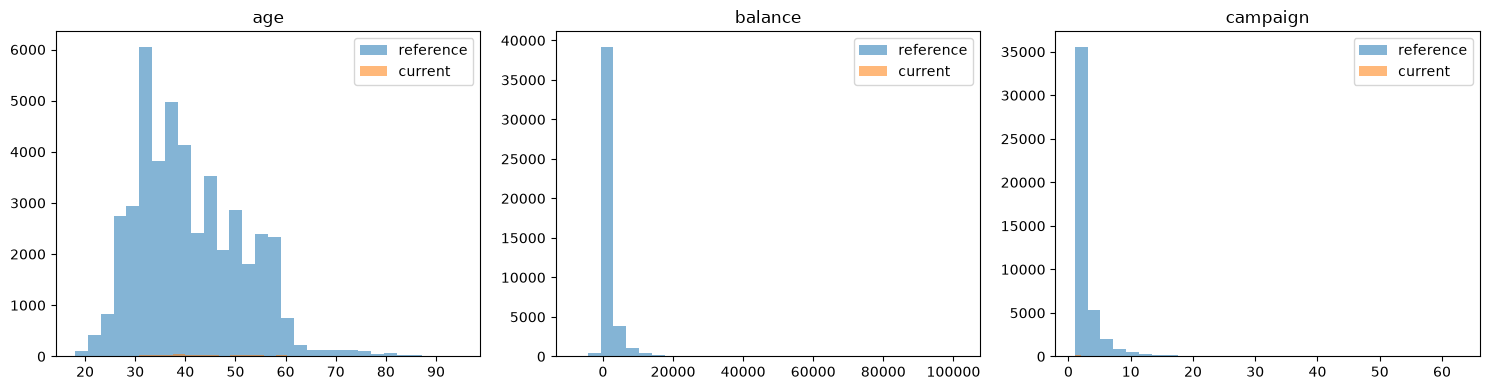

In [8]:
fig, axes = plt.subplots(1, len(numeric_features), figsize=(15, 4))

for ax, feature in zip(axes, numeric_features):
    ax.hist(reference_df[feature], bins=30, alpha=0.55, label="reference")
    ax.hist(current_df[feature], bins=30, alpha=0.55, label="current")
    ax.set_title(feature)
    ax.legend()

plt.tight_layout()

## 7. Categorical Drift Signals

For categorical features, we compare category shares. Large changes can indicate that the model is seeing a different population than during training.

In [11]:
def category_share_comparison(reference, current, feature):
    reference_share = reference[feature].value_counts(normalize=True).rename("reference_share")
    current_share = current[feature].value_counts(normalize=True).rename("current_share")
    comparison = pd.concat([reference_share, current_share], axis=1).fillna(0)
    comparison["absolute_difference"] = (
        comparison["current_share"] - comparison["reference_share"]
    ).abs()
    return comparison.sort_values("absolute_difference", ascending=False)


category_share_comparison(reference_df, dashboard_df, "contact")

,reference_share,current_share,absolute_difference
contact,,,
telephone,0.064276,0.4000,0.335724
cellular,0.647741,0.4325,0.215241
unknown,0.287983,0.1675,0.120483


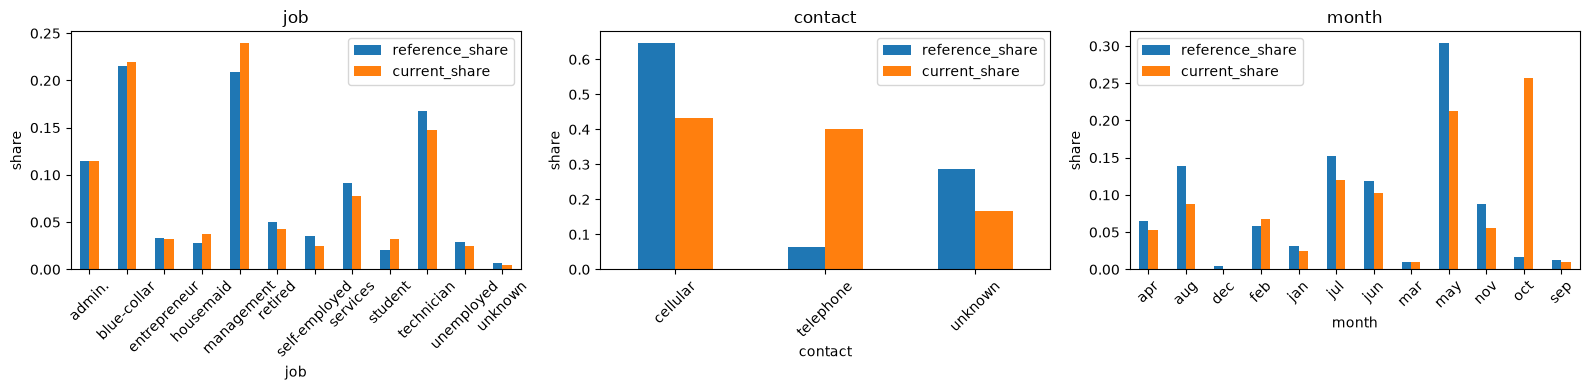

In [12]:
fig, axes = plt.subplots(1, len(categorical_features), figsize=(16, 4))

for ax, feature in zip(axes, categorical_features):
    comparison = category_share_comparison(reference_df, dashboard_df, feature).sort_index()
    comparison[["reference_share", "current_share"]].plot(kind="bar", ax=ax)
    ax.set_title(feature)
    ax.set_ylabel("share")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

#### Key observations

- The strongest categorical drift appears in `contact`: telephone contacts increased from about 6% to 40%, while cellular and unknown contacts decreased.
- The `month` distribution also changed substantially, especially because October represents a much larger share of the current sample and May a smaller share.
- The distribution of `job` changed less, although management customers increased slightly and some other categories decreased.
- Overall, the current population differs from the reference population mainly in `contact` and `month`.
- These results are expected because the synthetic sample was intentionally modified to demonstrate categorical drift.

## 8. Prediction Monitoring

Input drift asks whether the incoming data changed. Prediction monitoring asks whether model outputs changed.

Without ground-truth labels, this is not model performance monitoring. It is still useful: a sudden jump in average subscription probability or predicted subscription rate can be an operational signal.

In [13]:
if {"subscription_probability", "subscription_prediction"}.issubset(current_df.columns):
    prediction_summary = pd.DataFrame(
        [
            {
                "rows": len(current_df),
                "mean_subscription_probability": current_df["subscription_probability"].mean(),
                "predicted_subscription_rate": current_df["subscription_prediction"].mean(),
            }
        ]
    )
else:
    prediction_summary = pd.DataFrame()

prediction_summary

,rows,mean_subscription_probability,predicted_subscription_rate
0,400,0.184625,0.0175


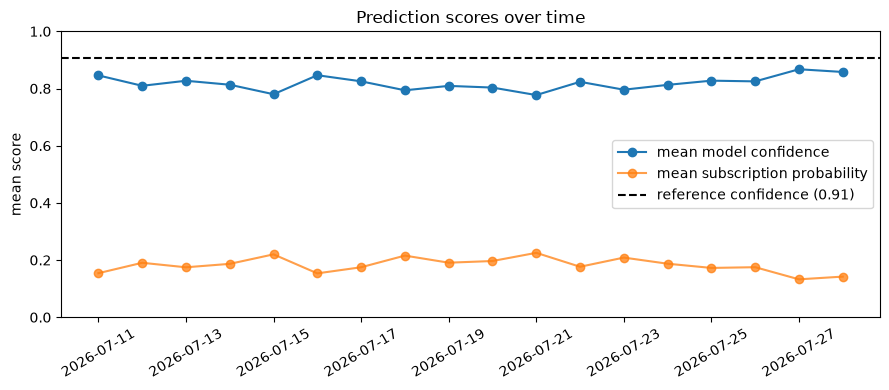

In [15]:
if not score_over_time.empty:
    fig, ax = plt.subplots(figsize=(9, 4))

    ax.plot(
        score_over_time["timestamp_utc"],
        score_over_time["model_confidence"],
        marker="o",
        label="mean model confidence",
    )

    ax.plot(
        score_over_time["timestamp_utc"],
        score_over_time["subscription_probability"],
        marker="o",
        label="mean subscription probability",
        alpha=0.75,
    )

    if not pd.isna(reference_mean_confidence):
        ax.axhline(
            reference_mean_confidence,
            color="black",
            linestyle="--",
            label=f"reference confidence ({reference_mean_confidence:.2f})",
        )

    ax.set_ylim(0, 1)
    ax.set_title("Prediction scores over time")
    ax.set_ylabel("mean score")
    ax.legend()
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()

#### Key observations

- The mean subscription probability remains relatively low and stable over the monitored period, generally between approximately 0.13 and 0.22.
- Mean model confidence remains high, around 0.78 to 0.87, but below the reference confidence of approximately 0.91.
- The current predicted subscription rate is low at 1.75%.
- No sudden change appears over time in the synthetic sample.
- Without observed outcomes, these signals describe prediction behavior but do not confirm whether model performance has improved or deteriorated.

## 9. Monitoring Report Overview

A monitoring dashboard should first answer a few operational questions:

- How much current data is available?
- Which time window is covered?
- Which model-output signals changed?
- Which checks require investigation?

Detailed distribution plots come after this overview.

In [17]:
monitoring_overview = pd.DataFrame(
    [
        {
            "reference_rows": len(reference_df),
            "current_rows": len(dashboard_df),
            "current_source": current_source,
            "window_start": dashboard_df["timestamp_utc"].min(),
            "window_end": dashboard_df["timestamp_utc"].max(),
            "mean_subscription_probability": (
                dashboard_df["subscription_probability"].mean()
                if "subscription_probability" in dashboard_df.columns
                else np.nan
            ),
            "mean_model_confidence": (
                dashboard_df["model_confidence"].mean()
                if "model_confidence" in dashboard_df.columns
                else np.nan
            ),
            "reference_mean_confidence": reference_mean_confidence,
            "predicted_subscription_rate": (
                dashboard_df["subscription_prediction"].mean()
                if "subscription_prediction" in dashboard_df.columns
                else np.nan
            ),
            "reference_prediction_source": reference_confidence_source,
        }
    ]
)

monitoring_overview

,reference_rows,current_rows,current_source,window_start,window_end,mean_subscription_probability,mean_model_confidence,reference_mean_confidence,predicted_subscription_rate,reference_prediction_source
0,45211,400,synthetic demo sample,2026-07-11 22:00:00+00:00,2026-07-28 13:00:00+00:00,0.184625,0.816465,0.905809,0.0175,07_mlflow_xgboost_predictions.csv


#### Key observations

- The reference dataset contains 45,211 records, while the current monitoring sample contains 400 records.
- The current data comes from the synthetic demonstration sample and covers the period from 11 July to 28 July 2026.
- The mean subscription probability is approximately 18.5%, while only 1.75% of records are classified as likely subscriptions using the 0.5 threshold.
- Mean model confidence is approximately 81.6%, below the reference mean confidence of approximately 90.6%.
- These results should be interpreted as demonstration signals because the current sample is synthetic and much smaller than the reference dataset.

## 10. Statistical Drift Tests

The following tests compare the reference data with the current inference data.

For continuous variables we use the **Kolmogorov-Smirnov test**. It compares two empirical distributions. A small p-value means that the current values are unlikely to come from the same distribution as the reference values.

For categorical variables we use a **chi-square test of independence**. It compares category counts between reference and current data. A small p-value means that the category mix has changed noticeably.

These tests are warning signals, not automatic model-quality verdicts. With very large samples even small differences can become statistically significant. With small samples relevant changes may still be hard to detect.

In [18]:
def drift_status(p_value, alpha=0.05):
    if pd.isna(p_value):
        return "not tested"
    return "investigate" if p_value < alpha else "ok"

ks_results = []
for feature in numeric_features:
    reference_values = reference_df[feature].dropna()
    current_values = dashboard_df[feature].dropna()
    if len(reference_values) == 0 or len(current_values) == 0:
        statistic, p_value = np.nan, np.nan
    else:
        statistic, p_value = ks_2samp(reference_values, current_values)
    ks_results.append(
        {
            "feature": feature,
            "test": "KS two-sample",
            "statistic": statistic,
            "p_value": p_value,
            "status": drift_status(p_value),
        }
    )

ks_results_df = pd.DataFrame(ks_results).sort_values("p_value")
ks_results_df

,feature,test,statistic,p_value,status
1,balance,KS two-sample,0.480783,1.017497e-84,investigate
2,campaign,KS two-sample,0.326755,3.765017e-38,investigate
0,age,KS two-sample,0.211417,5.215833e-16,investigate


In [20]:
chi2_results = []
for feature in categorical_features:
    reference_counts = reference_df[feature].value_counts()
    current_counts = dashboard_df[feature].value_counts()
    categories = sorted(set(reference_counts.index).union(current_counts.index))
    contingency = pd.DataFrame(
        {
            "reference": [reference_counts.get(category, 0) for category in categories],
            "current": [current_counts.get(category, 0) for category in categories],
        },
        index=categories,
    )

    if contingency.shape[0] < 2 or contingency.values.sum() == 0:
        statistic, p_value = np.nan, np.nan
    else:
        statistic, p_value, _, _ = chi2_contingency(contingency.T)

    chi2_results.append(
        {
            "feature": feature,
            "test": "chi-square",
            "statistic": statistic,
            "p_value": p_value,
            "status": drift_status(p_value),
        }
    )

chi2_results_df = pd.DataFrame(chi2_results).sort_values("p_value")
chi2_results_df

,feature,test,statistic,p_value,status
2,month,chi-square,1281.747524,3.861326e-268,investigate
1,contact,chi-square,713.307780,1.279922e-155,investigate
0,job,chi-square,9.713344,5.563415e-01,ok


#### Key observations

- All three numeric features (`age`, `balance`, and `campaign`) show statistically significant drift because their p-values are below 0.05.
- The strongest numeric differences appear in `balance` and `campaign`, which is consistent with the earlier summary statistics and histograms.
- For categorical features, `contact` and `month` show statistically significant drift.
- The `job` distribution does not show significant drift and is therefore marked as `ok`.
- These results are expected because the synthetic current sample was intentionally modified.
- The tests indicate that the current and reference distributions differ, but they do not by themselves prove that model performance has deteriorated.

,feature,test,statistic,p_value,status,signal_type,metric,value,threshold,interpretation
3,month,chi-square,1281.747524,3.861326e-268,investigate,data_drift,chi-square,3.861326e-268,0.05,Current distribution differs from the referenc...
4,contact,chi-square,713.307780,1.279922e-155,investigate,data_drift,chi-square,1.279922e-155,0.05,Current distribution differs from the referenc...
0,balance,KS two-sample,0.480783,1.017497e-84,investigate,data_drift,KS two-sample,1.017497e-84,0.05,Current distribution differs from the referenc...
1,campaign,KS two-sample,0.326755,3.765017e-38,investigate,data_drift,KS two-sample,3.765017e-38,0.05,Current distribution differs from the referenc...
2,age,KS two-sample,0.211417,5.215833e-16,investigate,data_drift,KS two-sample,5.215833e-16,0.05,Current distribution differs from the referenc...
5,job,chi-square,9.713344,5.563415e-01,ok,data_drift,chi-square,5.563415e-01,0.05,No strong distribution difference detected by ...


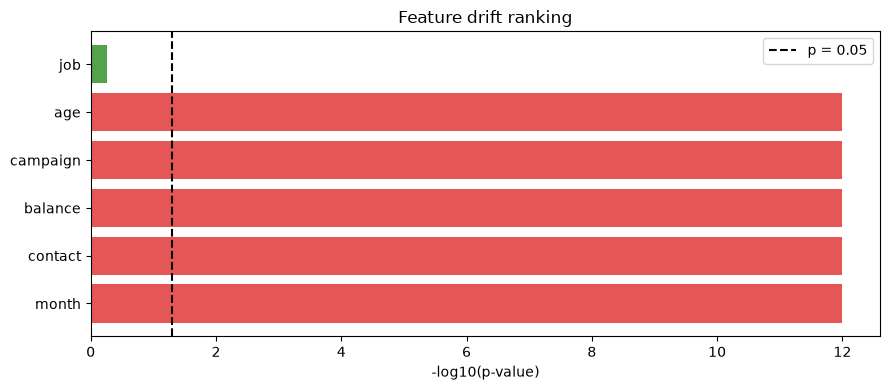

In [21]:
drift_test_results = pd.concat([ks_results_df, chi2_results_df], ignore_index=True)
drift_test_results["signal_type"] = "data_drift"
drift_test_results["metric"] = drift_test_results["test"]
drift_test_results["value"] = drift_test_results["p_value"]
drift_test_results["threshold"] = 0.05
drift_test_results["interpretation"] = np.where(
    drift_test_results["status"].eq("investigate"),
    "Current distribution differs from the reference distribution.",
    "No strong distribution difference detected by this test.",
)

fig, ax = plt.subplots(figsize=(9, 4))
plot_df = drift_test_results.copy().sort_values("p_value", ascending=True)
plot_df["minus_log10_p_value"] = -np.log10(plot_df["p_value"].clip(lower=1e-12))
colors = plot_df["status"].map({"ok": "#54A24B", "investigate": "#E45756", "not tested": "#BDBDBD"})

ax.barh(plot_df["feature"], plot_df["minus_log10_p_value"], color=colors)
ax.axvline(-np.log10(0.05), color="black", linestyle="--", label="p = 0.05")
ax.set_xlabel("-log10(p-value)")
ax.set_title("Feature drift ranking")
ax.legend()
plt.tight_layout()

drift_test_results.sort_values("p_value")

## 11. Alert Table

A practical monitoring workflow usually ends in a prioritized list of signals. This table combines data quality, data drift, and prediction monitoring checks into one place.

In [22]:
prediction_alert_rows = []

if "model_confidence" in dashboard_df.columns and not pd.isna(reference_mean_confidence):
    confidence_drop = reference_mean_confidence - dashboard_df["model_confidence"].mean()
    prediction_alert_rows.append(
        {
            "signal_type": "prediction_monitoring",
            "feature": "model_confidence",
            "metric": "reference_minus_current_mean",
            "value": confidence_drop,
            "threshold": 0.10,
            "status": "investigate" if confidence_drop > 0.10 else "ok",
            "interpretation": "Current confidence is lower than the reference confidence.",
        }
    )

if "subscription_prediction" in dashboard_df.columns and not pd.isna(reference_predicted_subscription_rate):
    subscription_rate_shift = abs(
        dashboard_df["subscription_prediction"].mean() - reference_predicted_subscription_rate
    )
    prediction_alert_rows.append(
        {
            "signal_type": "prediction_monitoring",
            "feature": "subscription_prediction",
            "metric": "absolute_predicted_rate_shift",
            "value": subscription_rate_shift,
            "threshold": 0.10,
            "status": "investigate" if subscription_rate_shift > 0.10 else "ok",
            "interpretation": "Predicted subscription rate shifted compared with the reference predictions.",
        }
    )

prediction_monitoring_results = pd.DataFrame(prediction_alert_rows)

alert_table = pd.concat(
    [
        data_quality_results[
            ["signal_type", "feature", "metric", "value", "threshold", "status", "interpretation"]
        ],
        drift_test_results[
            ["signal_type", "feature", "metric", "value", "threshold", "status", "interpretation"]
        ],
        prediction_monitoring_results,
    ],
    ignore_index=True,
)

status_order = {"investigate": 0, "not tested": 1, "ok": 2}
alert_table["status_order"] = alert_table["status"].map(status_order).fillna(3)
alert_table = alert_table.sort_values(
    ["status_order", "signal_type", "feature"]
).drop(columns="status_order")

alert_table

,signal_type,feature,metric,value,threshold,status,interpretation
13,data_drift,age,KS two-sample,5.215833e-16,0.05,investigate,Current distribution differs from the referenc...
11,data_drift,balance,KS two-sample,1.017497e-84,0.05,investigate,Current distribution differs from the referenc...
12,data_drift,campaign,KS two-sample,3.765017e-38,0.05,investigate,Current distribution differs from the referenc...
15,data_drift,contact,chi-square,1.279922e-155,0.05,investigate,Current distribution differs from the referenc...
14,data_drift,month,chi-square,3.861326e-268,0.05,investigate,Current distribution differs from the referenc...
16,data_drift,job,chi-square,5.563415e-01,0.05,ok,No strong distribution difference detected by ...
0,data_quality,age,missing_rate,0.000000e+00,0.05,ok,Share of current rows where the feature is mis...
6,data_quality,age,below_minimum_rate,0.000000e+00,0.00,ok,Share of current rows below the allowed minimu...
1,data_quality,balance,missing_rate,0.000000e+00,0.05,ok,Share of current rows where the feature is mis...
2,data_quality,campaign,missing_rate,0.000000e+00,0.05,ok,Share of current rows where the feature is mis...


In [23]:
alert_status_summary = (
    alert_table["status"]
    .value_counts()
    .reindex(["investigate", "not tested", "ok"], fill_value=0)
    .rename_axis("status")
    .reset_index(name="count")
)

alert_status_summary

,status,count
0,investigate,5
1,not tested,0
2,ok,14


#### Key observations

- The alert table contains 5 signals marked as `investigate` and 14 signals marked as `ok`.
- The five alerts are all related to data drift: `age`, `balance`, `campaign`, `contact`, and `month`.
- All basic data quality checks pass, with no missing values, invalid minimum values, or unseen categories detected.
- The `job` distribution does not show statistically significant drift.
- Prediction monitoring remains within the defined thresholds: the confidence decrease is approximately 0.089, below the 0.10 alert threshold, and the predicted subscription rate shift is approximately 0.035.
- Overall, the main issue detected is input data drift rather than data quality or prediction-output instability.
- These alerts are expected because the synthetic current sample was deliberately modified for the monitoring demonstration.

## 12. How to Read This Dashboard

A red signal does not mean that the model is broken. It means that the current inference population differs from the reference population for that feature.

Useful follow-up questions are:

- Is this drift expected from a campaign strategy change, a different contact approach, or seasonality?
- Does the drift affect important customer groups?
- Do model scores and business KPIs change at the same time?
- Do we need more labeled feedback before retraining?

In production, this kind of notebook would usually become a scheduled report or dashboard. The raw material would still be the same: logged requests, predictions, model version, and later realized outcomes.

## 13. Sources and Tool Inspiration

This notebook is a small didactic mockup. It does not replace a production monitoring platform.

The structure is inspired by common patterns in current ML monitoring and observability tools:

- Evidently AI: data quality, data drift, prediction monitoring, report-style dashboards.  
  https://www.evidentlyai.com/
- NannyML: post-deployment monitoring, delayed labels, and the idea that drift should be interpreted through performance or business impact.  
  https://www.nannyml.com/
- Azure ML Model Monitoring: data drift, prediction drift, data quality, feature attribution, reference data, and alert thresholds.  
  https://learn.microsoft.com/en-us/azure/machine-learning/concept-model-monitoring
- AWS SageMaker Model Monitor: baseline data, constraints, scheduled monitoring, reports, and alerts.  
  https://docs.aws.amazon.com/sagemaker/latest/dg/model-monitor.html
- Google Vertex AI Model Monitoring: baseline/current distributions, drift thresholds, and feature-level monitoring.  
  https://cloud.google.com/vertex-ai/docs/model-monitoring/overview

The recurring pattern is simple: collect inference data, compare it to a reference, prioritize suspicious signals, and investigate before deciding on retraining or rollback.

## 14. Production Outlook

This project uses SQLite because it is simple and local. For the course, it makes the data flow visible:

```text
incoming request -> prediction -> SQLite log -> monitoring notebook
```

In a cloud deployment, the same idea would usually use a central sink:

- Azure PostgreSQL or Azure SQL for structured request/prediction logs;
- Azure Blob Storage for larger event files;
- Event Hub or Application Insights for higher-volume operational telemetry.

The API would not hard-code this. It would read a configuration value such as `MONITORING_DB_PATH`, `MONITORING_DB_URI`, or `MONITORING_SINK_URI` from the deployment environment.

The important design distinction remains:

- model artifacts are read-only inputs to inference;
- monitoring logs are writable outputs of the running service.

## 15. Reflection

Monitoring does not make a model better by itself. It helps teams notice when they should investigate.

Useful questions are:

- Are incoming customers still similar to the training data?
- Are prediction probabilities shifting over time?
- Is one segment becoming much more common?
- Do we need new labels to check actual model quality?
- Should retraining or a threshold review be triggered?

This is why a model can be technically healthy but professionally risky: it may continue to respond while its assumptions become less valid.